## Step 1: Load Raw Data
   
We load the raw Superstore CSV using `latin1` encoding, since this dataset contains special characters (e.g., in city/customer names) that aren't valid UTF-8 and would otherwise throw a `UnicodeDecodeError`.
   
We also standardize column names to lowercase with underscores (e.g., `Order Date` → `order_date`) so they're easier and safer to reference in code — no spaces, no case-sensitivity issues.

In [10]:
import pandas as pd
df = pd.read_csv('../data/superstore_raw.csv', encoding='latin1')
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Step 2: Convert Date Columns & Check for Missing Values

`order_date` and `ship_date` are currently loaded as plain text (strings), not actual dates. Converting them to proper datetime objects lets us do date math later (like calculating shipping duration) and enables time-based operations like monthly resampling.

We also check for null values across all columns — this tells us if any data is missing before we start building features on top of it.

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
print(df.isnull().sum())

row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub-category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64


## Step 3: Feature Engineering

   We create two new columns:
   - `profit_margin` = profit divided by sales, showing what % of each sale was actual profit (useful for comparing profitability across products/categories regardless of price size).
   - `shipping_days` = the number of days between order date and ship date, showing how long fulfillment took for each order.

In [13]:
df['profit_margin'] = df['profit'] / df['sales']
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days
df[['profit', 'sales', 'profit_margin', 'order_date', 'ship_date', 'shipping_days']].head()

,profit,sales,profit_margin,order_date,ship_date,shipping_days
0,41.9136,261.9600,0.1600,2016-11-08,2016-11-11,3
1,219.5820,731.9400,0.3000,2016-11-08,2016-11-11,3
2,6.8714,14.6200,0.4700,2016-06-12,2016-06-16,4
3,-383.0310,957.5775,-0.4000,2015-10-11,2015-10-18,7
4,2.5164,22.3680,0.1125,2015-10-11,2015-10-18,7


## Step 4: Revenue Trend Over Time

We resample sales data to monthly totals, then apply a 3-month rolling average to smooth out month-to-month noise (e.g., seasonal spikes) and reveal the underlying trend. This chart is saved as an image for use in the dashboard later.

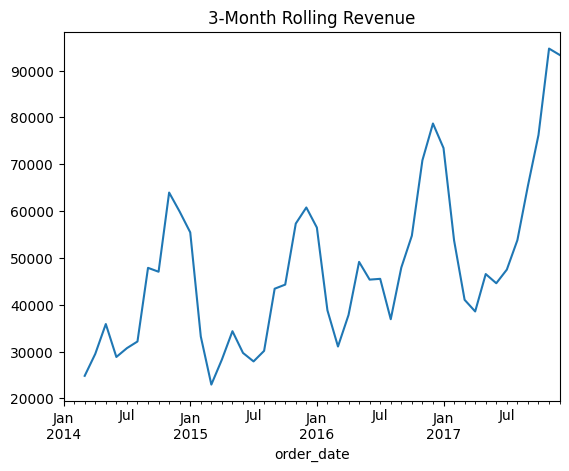

In [14]:
import matplotlib.pyplot as plt
monthly = df.set_index('order_date').resample('ME')['sales'].sum()
monthly.rolling(3).mean().plot(title='3-Month Rolling Revenue')
plt.savefig('../dashboards/rolling_revenue_trend.png')
plt.show()

## Step 5: Export Cleaned Data

We save the cleaned and feature-engineered dataset as a new CSV file, separate from the raw file. This keeps the raw data untouched (for reproducibility) while giving downstream steps — SQL analysis, Power BI dashboard — a ready-to-use clean dataset.

In [15]:
df.to_csv('../data/superstore_cleaned.csv', index=False)